# <b>1 <span style='color:#F1A424'>|</span> Nice One Beauty Market Performance (2025–2026)</b>
- 시작일 : 2026-06-10 수요일 오후 6시 
- 데이터셋 : Nice One Beauty (4193.SR) Tadawul Stock Price E-Commerce Market Dataset (2025-2026)

## <div style="color:white;display:fill;border-radius:8px;background-color:#323232;font-size:60%; letter-spacing:1.0px"><p style="padding: 12px;color:white;"><b><b><span style='color:white'><span style='color:#F1A424'>1.1 | </span></span></b> 프로젝트 개요 및 도메인</b></p></div>

**잘나가던 중동의 뷰티 스타트업이 상장 후 왜 주가가 폭등했다가 반토막 이하로 폭락했는가?**

- 회사명 : 나이스원 뷰티(Nice One Beauty)
    - 중동 지역의 이커머스 화장품 마케팅 브랜드
    - 인플루언서 마켓으로 시작 자체적인 모바일 app, 웹스토어 개발
    - 현재는 주문의 95% 온라인

- 배경 
    - 2025년 1월에 상장 35SAR로 지분 30프로 ➔ 상장 후 6주만에 주가가 68.4 까지 95프로 급등
    - 경영의 현실 (Operational Reality): 지역 유통 허브(제다 메가 물류창고 등) 구축을 위한 자본 지출(CapEx), 고객 경험 쇼룸 운영, 그리고 높은 마케팅 고객 획득 비용(CAC)으로 인해 영업 비용이 누적되면서 수익성이 압박
    - 시장 조정 (Market Correction) ➔  2026년 1월 초 : 16.8 떡락. 연말에는 17.4 로 안정화 

<div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#F1A424'>다루게 될 데이터와 분석 방향.</span></b></p></div>

1. **주가 데이터 분석 (시계열)** : 공모가(35 SAR) $\rightarrow$ 최고가(68.40 SAR) $\rightarrow$ 최저가(16.80 SAR)로 이어지는 주가 변동 추이 시각화 및 기술 통계
2. **재무 및 비용 데이터 분석** : 매출은 나는데 왜 주가가 떨어졌는지 |증명하기 위해, 물류창고 짓느라 쓴 돈(CapEx)과 마케팅 비용(CAC)이 마진(수익률)에 미친 영향 분석.
3. **시장 심리 및 지지선 분석** : 주식 시장에서 '주요 지지선'이 깨진 순간을 통계적 분석이나 주식 보조지표(이동평균선 등)로 시각화.


## <div style="color:white;display:fill;border-radius:8px;background-color:#323232;font-size:60%; letter-spacing:1.0px"><p style="padding: 12px;color:white;"><b><b><span style='color:white'><span style='color:#F1A424'>1.2 | </span></span></b> 환경 설정 및 라이브러리 임포트</b></p></div>

In [43]:
!uv pip install pandas numpy matplotlib seaborn plotly statsmodels

Checked 6 packages in 10ms


In [44]:
# 1.2.1 : 라이브러리 임포트

# 데이터 분석용 라이브러리
import pandas as pd
import numpy as np

# EDA 및 데이터시각화용 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 통계검증용 라이브러리
from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings('ignore')

In [45]:
# 1.2.2 : 시각화 스타일 설정

# 그래프의 배경을 흰색/회식 격자무늬로 세팅
sns.set_theme(style="whitegrid")
# 그래프 사이즈의 기본 크기를 가로 12, 세로 6인치 고정
plt.rcParams['figure.figsize'] = [12,6]
# 해상도(DPI)를 100으로 설정해서 선명하게 출력되도록 고정
plt.rcParams['figure.dpi'] = 100
# 그래프에 들어갈 폰트 지정
plt.rcParams['font.family'] = 'Malgun Gothic'

print("모든 라이브러리 임포트 완료입니다")

모든 라이브러리 임포트 완료입니다


## <div style="color:white;display:fill;border-radius:8px;background-color:#6C63FF;font-size:60%; letter-spacing:1.0px"><p style="padding: 12px;color:white;"><b><b><span style='color:white'><span style='color:white'>1.3 | </span></span></b> 데이터 로드 & 전처리</b></p></div>

- 원본 데이터셋(csv) 로드
- 전처리 단계:
    1. Date(날짜) 컬럼을 datetime(날짜형) 형식으로 변환 
    2. 시간 순서대로 정렬 (옛날 날짜부터 가장 최신 날짜까지)
    3. 파생 변수 생성 
        1. '일일 수익률(Daily Return)' 및 '로그 수익률(Log Return)'
        2. 변동성 지표: 일일 수익률의 7일 rolling 표준편차
        3. 변동성 지표: 일일 수익률의 30일 표준편차 <br> rolling window = 7 / 30
        4. 시간 관련 메타데이터 추출 (연, 월, 월 이름, 요일, 분기) <br> .dt.
    4. 정상성 확인 (Sanity Check): df.shape, 결측치 검사, df.head() 확인

In [46]:
# 1. 데이터셋 로드 및 컬럼 별 dtype 확인
df = pd.read_csv("data/Nice One Beauty Digital Marketing Company.csv")
df.head()

,Date,Close,High,Low,Open,Volume
0,1/8/2025,45.500000,45.500000,38.500000,38.500000,1415516
1,1/9/2025,49.000000,54.400002,45.099998,50.000000,32034350
2,1/12/2025,50.599998,52.400002,49.000000,49.700001,8232695
3,1/13/2025,49.450001,51.299999,49.099998,50.799999,3191676
4,1/14/2025,54.299999,54.299999,49.599998,49.750000,5258995


In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    267 non-null    str    
 1   Close   267 non-null    float64
 2   High    267 non-null    float64
 3   Low     267 non-null    float64
 4   Open    267 non-null    float64
 5   Volume  267 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 12.6 KB


**<mark style="background-color: #ffdf3d;color:black;border-radius:5px;opacity:1.0">2. Date 컬럼의 데이터타입을 str ➔ datetime  변경</mark>** 

**상태 : Date 컬럼이 str(문자열) 데이터 타입임을 확인.** :  주식데이터의 경우 시간의 흐름이 생명인 시계열(Time-Series) 데이터 <br> ➔ 문자열을 파이썬이 인식하는 `datetime 데이터타입`으로 바꿔야함.

1/14/2025 ➔ 월(m) / 일(d) / 연(Y)
- 전 :   Date    267 non-null    str 
- 후 : Date    267 non-null    datetime64[us]

In [48]:
# date 컬럼의 데이터타입을 str  datetime으로
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    267 non-null    datetime64[us]
 1   Close   267 non-null    float64       
 2   High    267 non-null    float64       
 3   Low     267 non-null    float64       
 4   Open    267 non-null    float64       
 5   Volume  267 non-null    int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 12.6 KB


**<mark style="background-color: #ffdf3d;color:black;border-radius:5px;opacity:1.0">3. Date 컬럼을 시간 순서대로 정렬</mark>** 

**reset_index(drop=True)**
데이터를 날짜순으로 새로 정렬했으니 원래 인덱스를 리셋해라

- sort_value('date')만 할 경우 ➔ 인덱스가 꼬임 & 조회 시 에러
    - 1번 줄: 2025-01-08
    - 2번 줄: 2025-01-09
    - 0번 줄: 2025-01-10
- `drop=True` : 기존 인덱스 그냥 버려라
    - 그냥 reset_index()만 실행하면 `기존의 인덱스를 index`라는 새로운 데이터 열로 만들어줌 

In [49]:
# 시계열 데이터 정렬하기 (과거에서 현재순)
df = df.sort_values('Date').reset_index(drop=True)
df

,Date,Close,High,Low,Open,Volume
0,2025-01-08,45.500000,45.500000,38.500000,38.500000,1415516
1,2025-01-09,49.000000,54.400002,45.099998,50.000000,32034350
2,2025-01-12,50.599998,52.400002,49.000000,49.700001,8232695
3,2025-01-13,49.450001,51.299999,49.099998,50.799999,3191676
4,2025-01-14,54.299999,54.299999,49.599998,49.750000,5258995
...,...,...,...,...,...,...
262,2026-01-25,18.260000,18.540001,18.150000,18.500000,806287
263,2026-01-26,18.250000,18.340000,18.100000,18.260000,308562
264,2026-01-27,18.260000,18.549999,17.299999,18.250000,1972097
265,2026-01-28,17.980000,18.299999,17.900000,18.260000,907635


<div style="color:white;display:fill;border-radius:8px;background-color:#323232;font-size:150%; letter-spacing:1.0px"><p style="padding: 12px;color:white;"><b><b><span style='color:white'><span style='color:#F1A424'>1.4 | </span></span></b>피쳐 엔지니어링_ 특성변수 만들기</b></p></div>

1. '일일 수익률(Daily Return)' 및 '로그 수익률(Log Return)'
2. 변동성 지표: 일일 수익률의 7일 rolling 표준편차
3. 변동성 지표: 일일 수익률의 30일 표준편차 <br> rolling window = 7 / 30
4. 시간 관련 메타데이터 추출 (연, 월, 월 이름, 요일, 분기) <br> .dt.

**<mark style="background-color: #ffdf3d;color:black;border-radius:5px;opacity:1.0"> 1. '일일 수익률(Daily Return)' 및 '로그 수익률(Log Return)'</mark>** 
- 판다스 내장함수 : `pct_change()`<br>
    - 한 객체 내에서 행과 행의 차이를 현재값과의 백분율로 출력하는 메서드
    - 계산 로직 : (다음행 - 현재행) / 현재행 
    - 첫 행의 경우 이전 행이 없으므로 `nan` 출력

- 로그 수익률 (Log Return)을 쓰는 이유 (로그 씌우는 이유):<br> 일반수익률의 문제 ➔ 50% 상승 다음날 50% 폭락일 경우 수익률이 0이 됨. <br> 하지만 수익률의 경우 50% 폭락 - >50만원, 50만원의 50% 폭등 75만원이 됨.
일반 수익률은 시간이 흐르면서 여러번 더하고 곱할 때 직관적인 계산이 틀어짐 
로그수익률의 경우 합산 결과가 정확히 0이 되는 대칭성을 가짐 

즉 요약 : 
1. 일일 수익률(Daily_Return): 사람이 눈으로 보고 "아, 오늘 주가가 몇 % 올랐구나/내렸구나" 직관적으로 이해하기 위한 변수.
2. 로그 수익률(Log_Return): 컴퓨터나 통계 모델이 "과거부터 현재까지의 전체 주가 흐름을 왜곡 없이 수학적으로 정확하게 연산"하기 위한 변수.

1. 일반 수식률 : 오늘 주가 - 어제 주가 / 어제 주가 
ex) 어제 주가 : 만원 오늘 주가 5000원
수익률 : 5000 - 10_000 / 10_000  - 50 


로그 수익률 = 


$$r_t = \ln\left(\frac{\text{오늘 종가}}{\text{어제 종가}}\right)$$

In [50]:
df['Daily_Return'] = df['Close'].pct_change() # 일일 수익률

판다스 내장 함수 : shift()
판다스에서 데이터를 아래로 미는 함수 ➔   `shift(1) ➔ 시계열 데이터가 날짜순으로 정렬되어 있기 때문에 오늘 줄 에서 데이터를 아래로 내리면 ➔ '어제 종가($P_{t-1}$)'를 가리키게 됨 . 

이걸 위해서 데이터를 최신 ➔ 오래된 순으로 정렬

오늘 종가($P_t$)를 방금 구한 어제 종가($P_{t-1}$)로 나눕니다 ($\frac{P_t}{P_{t-1}}$).

In [51]:
# df['close_yesterday'] = df['Close'].shift(1) # 인덱스 0은 nan ➔ 이전 종가가 없기 때문

# df['오늘_어제_종료가비율'] = df['Close']/df['close_yesterday']

df['Log_Return'] = np.log(df['Close']/df['Close'].shift(1)) # 로그 수익률

In [52]:
df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,Log_Return
0,2025-01-08,45.500000,45.500000,38.500000,38.500000,1415516,NaN,NaN
1,2025-01-09,49.000000,54.400002,45.099998,50.000000,32034350,0.076923,0.074108
2,2025-01-12,50.599998,52.400002,49.000000,49.700001,8232695,0.032653,0.032131
3,2025-01-13,49.450001,51.299999,49.099998,50.799999,3191676,-0.022727,-0.022989
4,2025-01-14,54.299999,54.299999,49.599998,49.750000,5258995,0.098079,0.093562


In [53]:
df.rename(columns={'Log_Retrun':'Log_Return'}, inplace=True)

**<mark style="background-color: #ffdf3d;color:black;border-radius:5px;opacity:1.0"> 2. 시계열 파생 변수 : 이동 변동성 : 7days, 30days </mark>** 

주식에서 변동성('Volatility') ➔ 주가가 얼마나 요동치는 지를 나타내는 위험도의 지표 


금융_주식 분석에서 중요한 개념 : rolling, window = 움직이는 틀

배경 : 주식 시장의 경우 하루 안에도 데이터(주가)가 변동이 심함 -> 당장 오늘 엄청 폭등했다고 해서 이게 진짜인지 일시적인 거품인지 알 수 없음.
➔ 오늘만 보지 말고 오늘을 포함한 최근 1주일 동안의 흐름을 묶어서 관찰하자 ➔ 이때 사용하는 판다스 도구 : rolling

rolling : 굴리다 미끄러지다 ➔ 고정된 자리에 가만히 있는 게 아니라 날짜가 흐름에 딸 ㅏ아래로 스르륵 미끄러지면서 움직이는 행위
window 창문의 크기 ➔ 한번에 내다볼 크기 (데이터 행의 개수) ex ) 7일치 ➔ window = 7

- 근데 7개 볼 게 없으면 nan 결측치 내뱉는다고 함~
- volatility : 변동성 : 금융에서 시간에 따른 일련의 거래 가격의 변동 정도

- 해석 : 
    - 주식시장에서 volatility(변동성) = risk(위험)
    - 변동성이 낮으면 ➔ 걔네 평균에서 떨어진 정도가 작다 = 표준편차가 작다 
    - 변동성이 크면 ➔ 표준편차가 크다. 가격의 오르락내리락이 심하다 

In [54]:
df['Rolling_Volatility_7d'] = df['Daily_Return'].rolling(window=7).std()

# 1. 데일리 리턴 ➔ 일일 수익률을 가지고 옴. 변화 비율을 비교하기 위해
# 2. rolling(window=7) ➔ [오늘+과거6일] 한 묶음으로 묶음
# 3. std() ➔ [오늘+과거6일] 즉 7일치 데이터의 표준 편차를 구함 ➔ 데이터가 평균에서 얼마나 멀리 떨어져서 흔들리는가. 
df['Rolling_Volatility_30d'] = df['Daily_Return'].rolling(window=30).std()

### <b><span style='color:#F1A424'> 데이터를 시간 단위로 쪼개기 : Extract temporal metadata</span></b>

시간 메타데이터(Temporal Metadata) :<br>
년/분기/월/주/일 등 시간적 패턴을 찾아내기 위해서 날짜(Date)컬럼을 여러개로 쪼개기<br>
`pd.to_datetime()` ➔ 날짜형 데이터 변환 ➔ 판다스에서 인식할 수 있는 datetime64 특수 타입이 됨.
- dt : Datetime 접근자
    - .strfime(), .day_name() 을 사용할 수 있음 .
    - dt.strftime('%b') : 날짜 형식을 원하는 문자열 모양으로 변환 str/ format / time : %b ➔ month를 축약형 영문으로 (Jan, Feb, Mar...)
    - dt.day_name() : 해당 날짜의 요일을 계산해서 풀 네임으로 영문 문자열을 변환 
    - dt.to_period('Q') : 날짜를 기반으로 몇분기(Quarter)에 속하는 지 계산 <br> (예: 2025-01-08이면 1분기니까 2025Q1로 변환)
    - .astype(str) : 문자열 타입으로 변환 

In [55]:
# 연도(Year)추출해서 새컬럼에 저장
df['Year'] = df['Date'].dt.year
# 날짜 데이터에서 월(Month) 정보만 추출해서 새컬럼에 저장
df['Month'] = df['Date'].dt.month

In [56]:
df['Month_name'] = df['Date'].dt.strftime('%b') # 날짜를 원하는 문자열 포맷으로 변환 ex) 1월이면 Jan
df['Day_of_Week'] = df['Date'].dt.day_name() # 해당 날짜의 요일을 영문으로 반환  ex) Monday

In [57]:
# 분기 반환
df['Quarter'] = df['Date'].dt.to_period('Q').astype(str)

In [58]:
df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,Log_Return,Rolling_Volatility_7d,Rolling_Volatility_30d,Year,Month,Month_name,Day_of_Week,Quarter
0,2025-01-08,45.500000,45.500000,38.500000,38.500000,1415516,NaN,NaN,NaN,NaN,2025,1,Jan,Wednesday,2025Q1
1,2025-01-09,49.000000,54.400002,45.099998,50.000000,32034350,0.076923,0.074108,NaN,NaN,2025,1,Jan,Thursday,2025Q1
2,2025-01-12,50.599998,52.400002,49.000000,49.700001,8232695,0.032653,0.032131,NaN,NaN,2025,1,Jan,Sunday,2025Q1
3,2025-01-13,49.450001,51.299999,49.099998,50.799999,3191676,-0.022727,-0.022989,NaN,NaN,2025,1,Jan,Monday,2025Q1
4,2025-01-14,54.299999,54.299999,49.599998,49.750000,5258995,0.098079,0.093562,NaN,NaN,2025,1,Jan,Tuesday,2025Q1


### <b><span style='color:#F1A424'> Sanity Check: 논리적으로 말이 되는지 빠르게 확인: 기초검증절차 </span></b>

 데이터가 의도한 대로 잘 다듬어졌는지 최종적으로 확인 ➔ 새니티 체크  

In [59]:
# df의 [전체 행수, 열(컬럼 수 )]
print("데이터 shape:", df.shape)

데이터 shape: (267, 15)


In [60]:
print("data Completeness check(=데이터의 완전성 체크_ missing value가 있는가):")
print(df.isnull().sum())

data Completeness check(=데이터의 완전성 체크_ missing value가 있는가):
Date                       0
Close                      0
High                       0
Low                        0
Open                       0
Volume                     0
Daily_Return               1
Log_Return                 1
Rolling_Volatility_7d      7
Rolling_Volatility_30d    30
Year                       0
Month                      0
Month_name                 0
Day_of_Week                0
Quarter                    0
dtype: int64


In [61]:
print("first 5 records")
df.head()

first 5 records


,Date,Close,High,Low,Open,Volume,Daily_Return,Log_Return,Rolling_Volatility_7d,Rolling_Volatility_30d,Year,Month,Month_name,Day_of_Week,Quarter
0,2025-01-08,45.500000,45.500000,38.500000,38.500000,1415516,NaN,NaN,NaN,NaN,2025,1,Jan,Wednesday,2025Q1
1,2025-01-09,49.000000,54.400002,45.099998,50.000000,32034350,0.076923,0.074108,NaN,NaN,2025,1,Jan,Thursday,2025Q1
2,2025-01-12,50.599998,52.400002,49.000000,49.700001,8232695,0.032653,0.032131,NaN,NaN,2025,1,Jan,Sunday,2025Q1
3,2025-01-13,49.450001,51.299999,49.099998,50.799999,3191676,-0.022727,-0.022989,NaN,NaN,2025,1,Jan,Monday,2025Q1
4,2025-01-14,54.299999,54.299999,49.599998,49.750000,5258995,0.098079,0.093562,NaN,NaN,2025,1,Jan,Tuesday,2025Q1


<div style="color:white;display:fill;border-radius:8px;background-color:#323232;font-size:150%; letter-spacing:1.0px"><p style="padding: 12px;color:white;"><b><b><span style='color:white'><span style='color:#F1A424'>1.5 | 
</span></span></b>  분석 함수 및 구조적 인사이트(Analytical Functions & Structural Insights)</b></p></div>

분석의 4가지 관점
1. 구성 분석 (Composition Analysis) : 전체적인 구조, 데이터 타입, 총 주식 거래량 평가
2. 분포 분석 (Distribution Analysis) : 가격, 걸량, 수익률의 형태(왜도, 첨도 및 확률 밀도)
3. 비교 분석 (Comparison Analysis) : 월별 분기별 주가 성과와 변동성을 벤치마킹(비교)
4. 관계 분석 (Relationship Analysis) : 거래량, 주가 움직임, 시장 변동성 간의 상관관계 

In [62]:
#1.5.1 구성 분석 : 데이터프레임의 구성을 분석, 전체 집계 지표를 다룸

# 분석 함수 정의
def analyze_composition(data):
    print("==데이터셋 구성 요약 ==")
    print(f"총 주식 거래 일수(Total trading sessions_observations): {len(data)}")
    print(f"전체 컬럼 수 (피쳐 수) : {data.shape[1]}")
    print(f"피쳐 종류 : {list(data.columns)}")
    print("\nFeature type & 메모리 확인") 
    print(data.info())# 각 컬럼의 데이터타입, 그리고 메모리를 얼마나 잡아먹나
    
    
    total_volume_traded = data['Volume'].sum()  # 누적 주식 거래량(Volume) 
    print(f"\n누적 주식 거래량(2025-2026): {total_volume_traded:,} shares") # :, ➔ 3자리마다 콤마
    print(f"최초 공모가(IPO 제안 금액) : SAR 35.00")
    print(f"최종 마감 주가(종가): SAR {data['Close'].iloc[-1]:.2f}") # 종가의 뒤에서 첫번째 즉 가장 최신의 종료가를 가져오되 소수점 2자리까지만 보여주삼
    
    
analyze_composition(df)

==데이터셋 구성 요약 ==
총 주식 거래 일수(Total trading sessions_observations): 267
전체 컬럼 수 (피쳐 수) : 15
피쳐 종류 : ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'Log_Return', 'Rolling_Volatility_7d', 'Rolling_Volatility_30d', 'Year', 'Month', 'Month_name', 'Day_of_Week', 'Quarter']

Feature type & 메모리 확인
<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    267 non-null    datetime64[us]
 1   Close                   267 non-null    float64       
 2   High                    267 non-null    float64       
 3   Low                     267 non-null    float64       
 4   Open                    267 non-null    float64       
 5   Volume                  267 non-null    int64         
 6   Daily_Return            266 non-null    float64       
 7   Log_Return              266 non-null    float64     

## 2. 분포 분석 (Distribution Analysis) : 가격, 걸량, 수익률의 형태(왜도, 첨도 및 확률 밀도)

가격, 일일수익률(Daily Return)거래량(Volume)의 분포를 분석 ➔ 통계적 지표들(평균, 표준편차, 왜도, 첨도)을 계산하고 확률 밀도 그래프(Probability Density Plots)를 생성

왜도(Skewness) 및 첨도(Kurtosis) 계산:
왜도 : 데이터 분포 좌우 비대칭 정도를 표현하는 척도 ➔ 데이터의 분포가 얼마나 대칭인지 아닌지, 정규분포(좌우대칭)일 수록 왜도값은 작아짐. 한쪽으로 심하게 몰려있으면 왜도값 증가
- 양의 왜도 > 0 : 
    1. 오른쪽으로 긴 꼬리
    2. 평균 > 중앙값 
- 왜도 = 0 :
    1. 좌우 대칭
    2. 평균 = 중앙값 
- 음의 왜도 <0> : 음수 & 좌측 편향 
    1. 왼쪽으로 긴 꼬리
    2. 평균 < 중앙값 < 최빈값  
<img src = "https://dthumb-phinf.pstatic.net/?src=%22http%3A%2F%2Fwww.statisticshowto.com%2Fwp-content%2Fuploads%2F2014%2F02%2Fpearson-mode-skewness.jpg%22&type=m10000_10000">

첨도 : 분포가 정규분포보다 얼마나 뾰족 or 완만한 정도를 나타내는 척도 즉 얼마나 중심에 집중적으로 몰려있는가 
데이터가 중심에 많이 몰려있을 수록 뾰족 = 양의 첨도 !, 두루 퍼지면 음의 첨도 

In [63]:
#  분포 분석

def analyze_distribution(data):
    
    # 1. 기본적인 데이터 기술통계량 print
    stats_df = data[['Open','High','Low','Close', 'Volume', 'Daily_Return']].describe()
    print("=== FINANCIAL STATISTICAL SUMMARY === ")
    ("=== [나이스원 뷰티] 주가 데이터 금융 통계 요약 성적표 ===")
    print(stats_df)
    
    # 2. 왜도(Skewness)와 첨도(Kurtosis) 계산
    print(f"\n종가 데이터 왜도(Skewness): {data['Close'].skew():.4f}")
    print(f"일일 수익률 왜도(Skewness): {data['Daily_Return'].dropna().skew():.4f}")
    print(f"일일 수익률 첨도(Kurtosis) : {data['Daily_Return'].dropna().kurtosis():.4f}")
    
    # 3. 보고서용 서브 플롯(1행 3열) 틀 짜기
    fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # 왼쪽부터 차례대로 axes[0]-[2]
    
    ## 0번방 : axes[0] : 종가 확률 밀도 (kde)
    sns.histplot(data['Close'], kde=True, ax=axes[0], color='#2c3e50', stat= "density") # 1  
    axes[0].set_title("종가 확률 밀도 분포", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("주가 (SAR)")
    axes[0].axvline(data['Close'].mean(), color = 'red', linestyle='--', label =f"평균 주가 : {data['Close'].mean():.2f}")
    axes[0].axvline(35.0, color='green', linestyle='-', label="최초 공모가 : 35.0")
    axes[0].legend()
    
    '''
    [0번방_axes[0]]
    1. 히스토그램(막대그래프)를 그리되, 데이터의 흐름을 부드럽게 하는 kde=TRUE(확률밀도함수 선을 함께 얹어라.
    2. ax=axes[0] 축은 0번 방에 , stat : 히스토그램 쌓아 올리는 건 단순 개수가 아니라 확률 비중(density)
    3. axvline() : 그래프 위에 세로선(Vertical Line)을 그려라. -> 주가 평균값에 빨간 점선 , 최초 공모가에 초록 실선
    4. legend() : 범례 표시
    '''
    
    ## 1번방 : axes[1] : 일일 수익률 분포 (kde 능선 포함)
    sns.histplot(data['Daily_Return'].dropna(), kde=True, ax=axes[1], color='#e74c3c', stat="density")
    axes[1].set_title("일일 수익률 확률 밀도 분포", fontsize=12, fontweight='bold')
    axes[1].set_xlabel('일일 수익률 (%)')
    
    ## 2번방 : axes[2] : 거래량 히스토그램 (로그 스케일 적용)
    sns.histplot(data['Volume'], kde=True, ax=axes[2], color='#1abc9c', stat = "density", log_scale=True)
    axes[2].set_title("주식 거래량 확률 밀도 분포(로그스케일)", fontsize=12, fontweight='bold')
    axes[2].set_xlabel('거래량 (주식 수 - Log)')
    
    '''
    log_scale =true 
    주식 거래량은 최솟값과 최댓값 차이가 수만배. -> 일반 스케일x, -> log를 씌워 압축
    '''
    
    ## 4. 마무리, 자동 정렬 및 출력
    plt.tight_layout()
    plt.show() 

=== FINANCIAL STATISTICAL SUMMARY === 
             Open        High         Low       Close        Volume  \
count  267.000000  267.000000  267.000000  267.000000  2.670000e+02   
mean    32.261536   32.869626   31.658577   32.158165  1.516218e+06   
std     13.165684   13.605854   12.767479   13.137815  2.538507e+06   
min     17.040001   17.190001   16.799999   16.799999  1.115950e+05   
25%     23.250000   23.485000   22.905000   23.035000  4.314620e+05   
50%     29.650000   30.000000   29.200001   29.600000  7.611890e+05   
75%     37.025000   37.850000   36.325001   37.025000  1.641290e+06   
max     69.500000   69.699997   65.699997   68.400002  3.203435e+07   

       Daily_Return  
count    266.000000  
mean      -0.003231  
std        0.027430  
min       -0.099663  
25%       -0.016797  
50%       -0.003454  
75%        0.009854  
max        0.100000  

종가 데이터 왜도(Skewness): 1.0990
일일 수익률 왜도(Skewness): 0.0405
일일 수익률 첨도(Kurtosis) : 3.3764


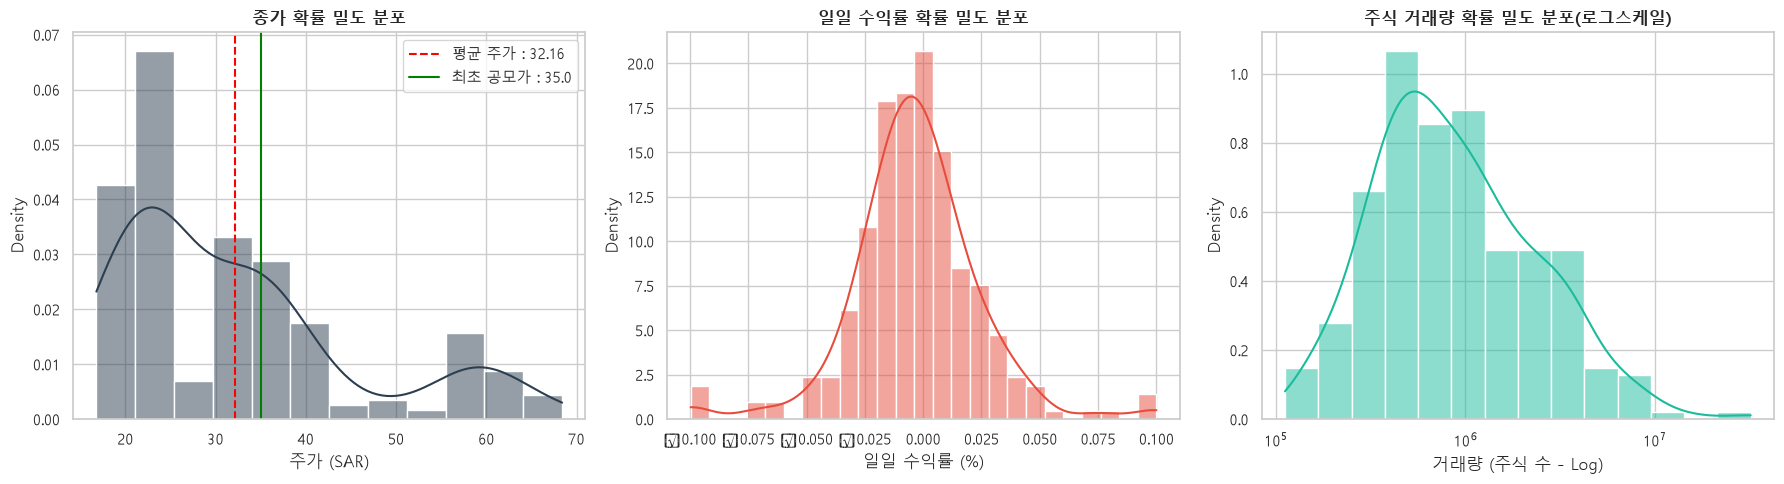

In [64]:
analyze_distribution(df)

해석하기 
1. 종가확률밀도분포 
    - 왜도값 : 1.09(양수) 오른쪽으로 꼬리가 길고 왼쪽에 뭉침
    - 가장 밀도가 높은 구간 -> 왼쪽 주가가 25~25 구간 -> 즉 중앙값  
    - 주가가 고점이 적어서 오른쪽으로 긴 꼬리가 생김
    - 중앙값이 평균값보다 왼쪽에 존재. -> 상장 초기~ 급격한 Hype peak 주가 폭등에 전체 주가의 평균치가 비정상적으로 높게 끌어 올려짐.
    실제 주식은 상장 기간 대부분을 평균 주가, 공모가보다 낮은 바닥권에서 보냄.(중앙값이 평균가, 공모가보다 낮음을 해석)

2. 일일 수익률 확률 밀도 분포
    - 왜도(Skewness): 0.0405 -> 0에 가까움 안정적
    - 첨도(Kurtosis) : 3.3764 -> 첨도가 0보다 크면 더 뾰족!, 양쪽 끝 꼬리가 두꺼운(Fat-Tail) 분포  (정규분포의 첨도 = 0)
    - 수익률 0%에서 분포가 쏠림 (peak) -> 약보합세(큰 변동 없이 정체된 상태) 유지하면서 흘러간 날이 압도적으로 많다.
    - -10%, 10% 양쪽 끝 꼬리가 두꺼운(Fat-Tail) -> 일일 수익률이 10% 폭락, 폭등 -> 하루만에 
        - `-10% 영역` : 비용 압박이 폭로되었을 때 투자자들이 공포에 질려 던진 패닉 셀(Panic Selling)
        - ` 10% 영역` : 상장 초기 광적인 매수세로 인한 폭등 
        - 위 두 영역이 다 아웃라이어(예측 불가능한 예외 수치) -> '블랙 스완(Black Swan)' = 극단적 위험

## 비교 분석 (Comparison Analysis)
연중 - 월 - 분기에 따라 달라지는 주가 
변동성, 거래활동  분석

In [65]:
# 비교 분석

def analyze_comparisons(data):
    
    # pivot average : 분기별로 데이터 묶어주기. 
    # 분기 별 평균 종가, 평균 거래량을 피벗 집계 
    quarterly_summary = data.groupby('Quarter')[['Close', 'Volume']].mean()
    print("===[나이스원 뷰티] 분기별 주가 및 거래량 비교 요약 ===")
    print(quarterly_summary)
    
    # 2. 시각화 틀짜기~ (세로로 2층 방 배치)
    fig, axes = plt.subplots(
        2,1, figsize=(15,12)
    ) # 위층방: axes[0], 아래층방: axes[1]
    
    # 달력(month) 순서 정렬 틀 만들기 : 월을 시간 순서대로 정렬하기 위해 문자열(str) -> 범주형 데이터로 변환 
    month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    data['Month_Order'] = pd.Categorical(data['Month_name'], categories=month_order, ordered=True) # 순서도 지키라고 함.
    
    # 4. 월별 종가 박스 플롯 
    sns.boxplot(x='Month_Order', y='Close', data=data, ax=axes[0],  palette='Blues_r')
    axes[0].set_title("월별 종가 분포 및 추이 (2025-2026)", fontsize=14, fontweight='bold')
    axes[0].set_xlabel('월 (Month)')
    axes[0].set_ylabel('종가 주가 (SAR)')
    axes[0].axhline(35.0, color='red',linestyle='--', label="최초 공모가 (IPO Price: 35.0 SAR)")
    axes[0].legend()
    
    # 월별 변동성 (7일 30일) 박스 플롯
    sns.boxplot(x='Month_Order', y='Rolling_Volatility_7d', data=data, ax=axes[1], palette='Oranges_r')
    axes[1].set_title("월별 7일 이동 변동성(위험도) 분포 추이", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("월(Month)")
    axes[1].set_ylabel('변동성 수준 (표준편차)')
    
    plt.tight_layout()
    plt.show()

===[나이스원 뷰티] 분기별 주가 및 거래량 비교 요약 ===
             Close        Volume
Quarter                         
2025Q1   53.509822  3.596330e+06
2025Q2   34.450847  1.640492e+06
2025Q3   26.952461  9.160809e+05
2025Q4   21.682727  5.388142e+05
2026Q1   17.814762  5.495139e+05


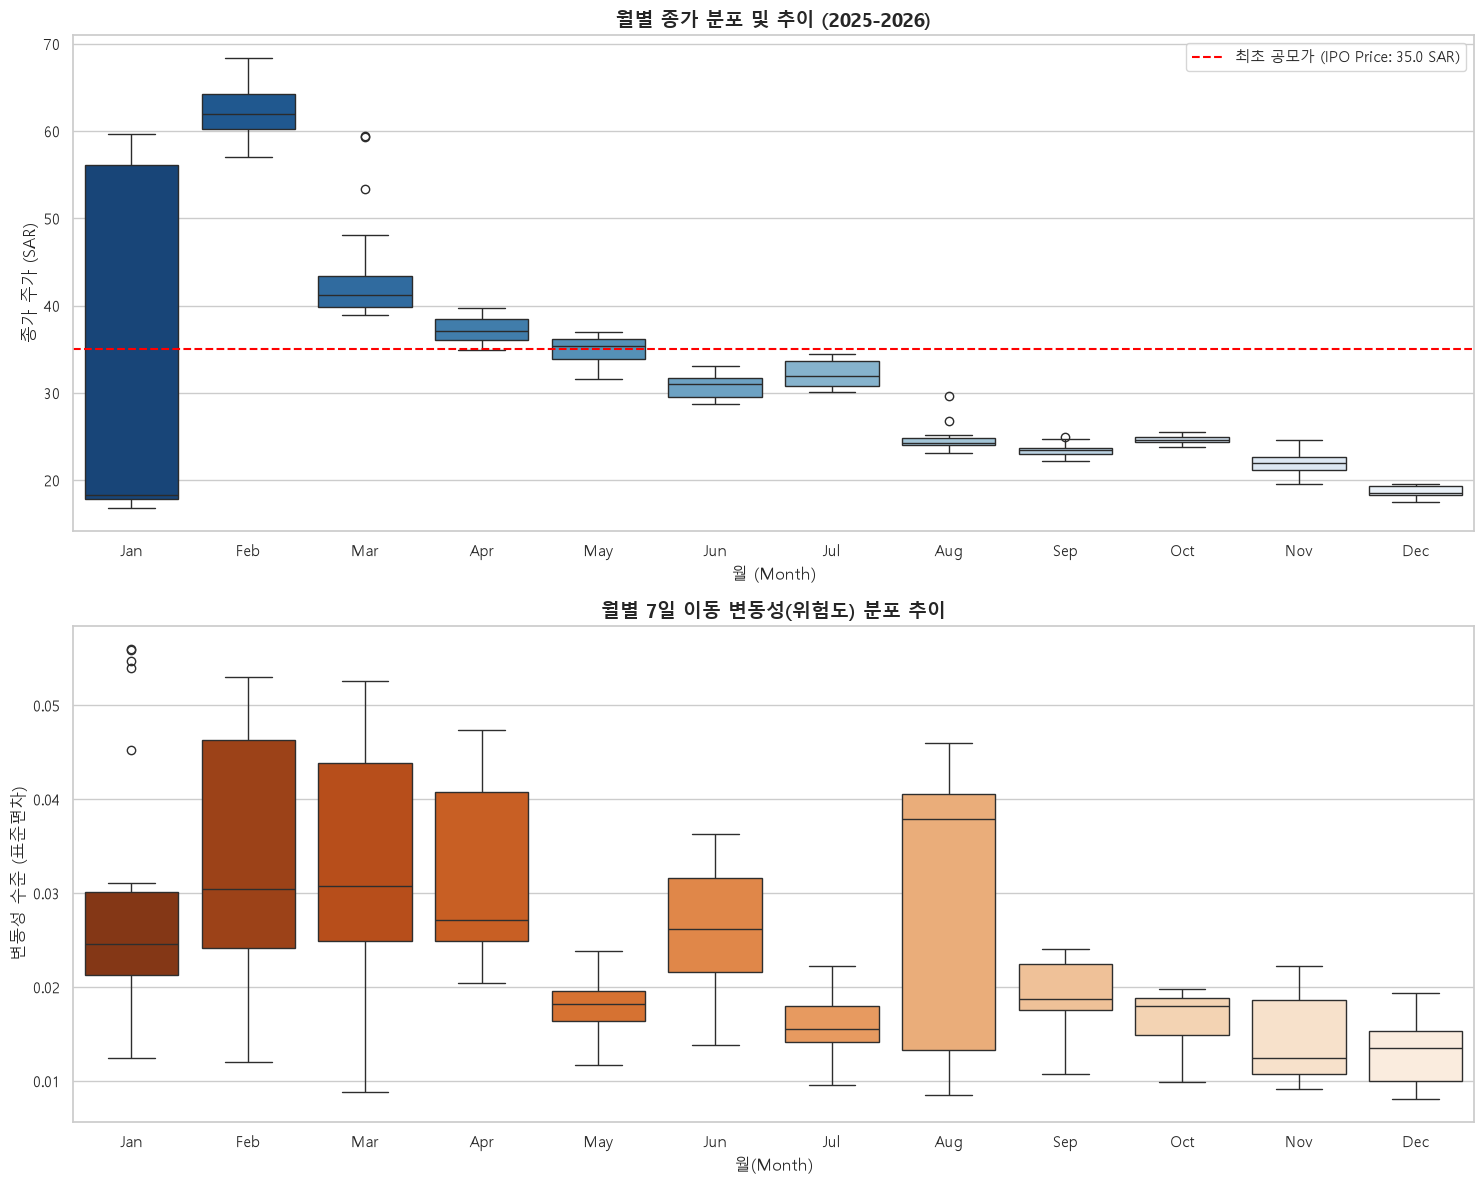

In [66]:
analyze_comparisons(df)

## 관계 분석(Relationship Analysis)

- 위 주요 지표들 간의 관계 조사.
- 사용 : 회귀선(Regression Fits)이 포함된 산점도(Scatter Plots), 상관관계 히트맵(Correlation Heatmap)
- 주가가 변화함에 따라 거래량과 주가 변동성이 어떻게 움직이는지.
- Regplot(Regression + Scatter plots) : 산점도에다가 그 점들의 중심을 관통하는 추세선(회귀선)을 동시에 그림

In [67]:
def analyze_relationships(data):
    
    # corr matrix
    corr_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'Rolling_Volatility_7d']
    corr_matrix = data[corr_cols].corr()
    print("=== [나이스원 뷰티] 주요 금융 변수 간 상관관계 행렬 ===")
    print(corr_matrix)
    
    fig,axes = plt.subplots(1,2, figsize = (18,6))
    
    # corr heatmap
    sns.heatmap(
        corr_matrix, 
        annot=True, # 실제 상관관계 숫자도 같이 적어라
        cmap='coolwarm', # 양수(정비례): 빨간색, 음수(반비례); 파란색
        fmt=".2f", # 소수점 둘째 자리까지만
        linewidths=5,
        ax=axes[0]
        )
    axes[0].set_title("금융 변수 간 상관관계 히트맵 (Correlation Heatmap)", fontsize = 12, fontweight='bold')
    
    # 산점도 : 거래량 vs 변동성  with regression line (회귀선)
    sns.regplot(
        x="Rolling_Volatility_7d",  # 1. X축 변수 : 7일 이동 변동성
        y='Volume',                 # 2. y축 변수 : 주식 거래량                 
        data=data,                  # 3. 데이터 소스 
        ax=axes[1],                 # 4. 방번호 지정
        color='#8e44ad',
        scatter_kws={'alpha':0.5, 'color': '#2c3e50'}, # 6. 산점도 점 디테일 설정 # alpha : 투명도
        line_kws={'color': '#e74c3c'}                  # 7. 회귀선 디테일 설정
    )
    axes[1].set_title("시장 변동성(위험도)과 주식 거래량의 역학관계", fontsize=12, fontweight='bold')
    axes[1].set_xlabel('7일 이동 변동성 (표준편차)')
    axes[1].set_ylabel('주식 거래량 (주식수 - 로그 스케일 적용)')
    axes[1].set_yscale('log') # 거래량 폭증의 왜곡 방지를 위한 로그 스케일
    
    #여백 자동 정렬 및 출력
    plt.tight_layout()
    plt.show()
    

=== [나이스원 뷰티] 주요 금융 변수 간 상관관계 행렬 ===
                           Open      High       Low     Close    Volume  \
Open                   1.000000  0.998143  0.998549  0.996301  0.425499   
High                   0.998143  1.000000  0.997681  0.998664  0.451710   
Low                    0.998549  0.997681  1.000000  0.998162  0.407092   
Close                  0.996301  0.998664  0.998162  1.000000  0.430257   
Volume                 0.425499  0.451710  0.407092  0.430257  1.000000   
Daily_Return           0.025927  0.058945  0.046353  0.080232  0.228968   
Rolling_Volatility_7d  0.504093  0.511140  0.495899  0.501109  0.523467   

                       Daily_Return  Rolling_Volatility_7d  
Open                       0.025927               0.504093  
High                       0.058945               0.511140  
Low                        0.046353               0.495899  
Close                      0.080232               0.501109  
Volume                     0.228968               0.52346

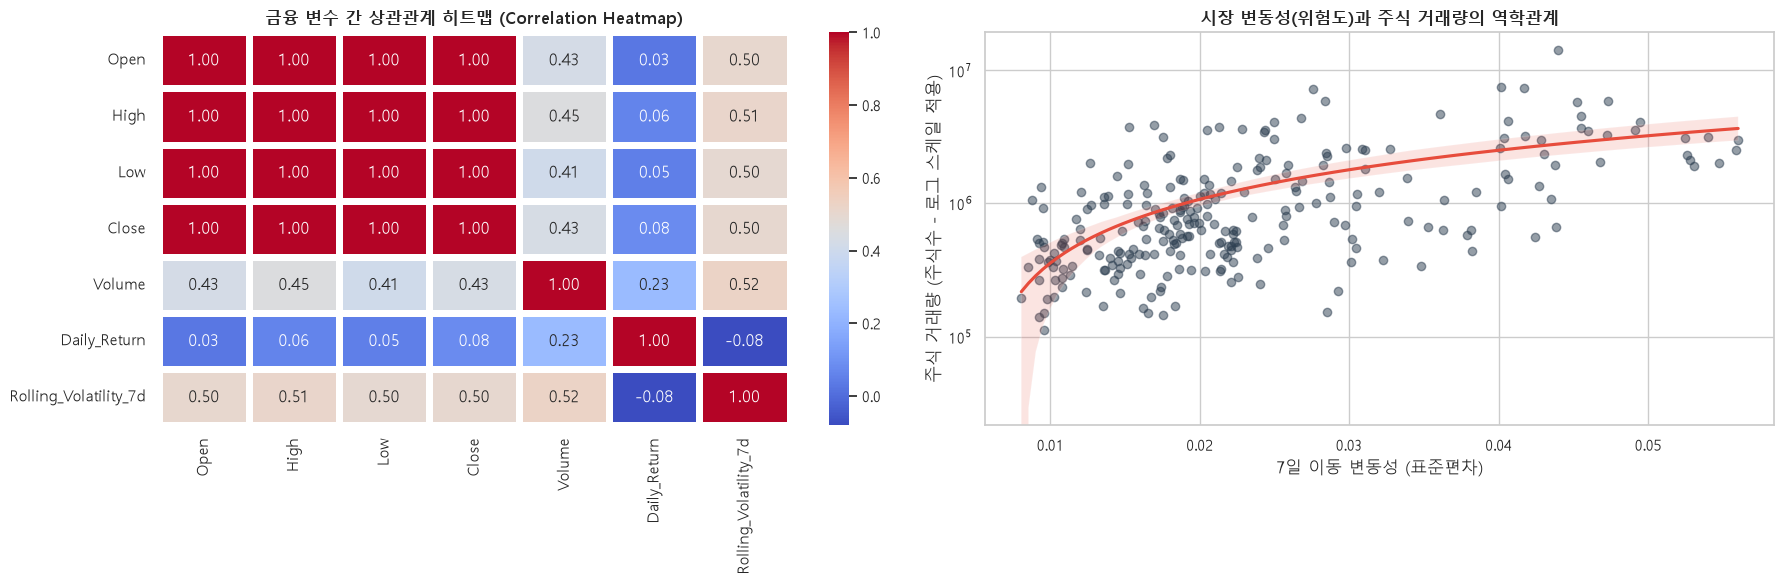

In [68]:
analyze_relationships(df)

### 인사이트 도출

1. 상관관계 히트맵
    1. 1.OPEN, HIGH,LOW,CLOSE 4 지표들이 왜 다 1.00?
    2. [Volume - Close] : 거래량과 주가 간의 관계 (0,43) 정비례 <br> 보통 주가가 높을 때 거래량도 같이 많았다.
    3. [Close - 변동성(Rolling_Volatility_7d)] : (0.5) 정비례 <br> 일반적으로 주가와 변동성은 음의 상관관계, 즉 주가가 폭락하면 변동성이 높아지고, 주가가 높아지면 변동성이 떨어짐.
    하지만 나이스원 뷰티의 경우 주가와 변동성의 상관관계가 양이나옴. 즉 주가가 오를 때 변동성(위험도)도 함께 증가. 

##  Pattern, Trend, Outlier 등

- 사우디 Trading Calendar (일요일 ~ 목요일) : 사우디의 영업일 차이에 따른 패턴 차이가 있는 지 데이터로 검증하고, 특정 요일마다 거래량이나 수익률의 뚜렷한 특징이 나타나느지 평가

=== 사우디 거래소(Tadawul) 요일별 주식 거래 요약 성적표 ===
                   Volume  Daily_Return
Day_of_Week                            
Sunday       1.211798e+06     -0.007160
Monday       1.607908e+06     -0.003073
Tuesday      1.388420e+06     -0.005882
Wednesday    1.250685e+06      0.002935
Thursday     2.102040e+06     -0.003213


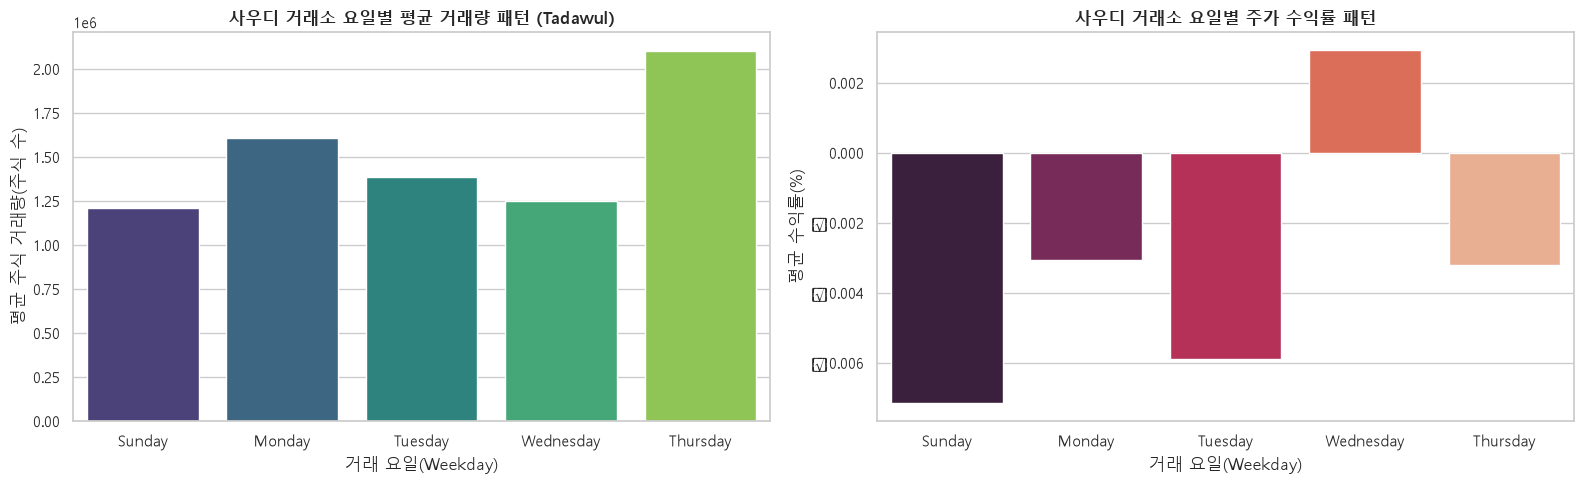

In [69]:
# 요일 별 평균 거래량, 평균 수익률 다중 집계 (일-목 reindex)
dow_summary = df.groupby('Day_of_Week')[['Volume','Daily_Return']].agg({'Volume':'mean','Daily_Return':'mean'}).reindex(['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday'])

print("=== 사우디 거래소(Tadawul) 요일별 주식 거래 요약 성적표 ===")
print(dow_summary)

# 시각화용 틀 짜기 (1행 2열)
fig, axes = plt.subplots(1,2, figsize=(16,5))

# 왼쪽 axes[0] : 요일별 평균 주식, 거래량 변동 
sns.barplot(x=dow_summary.index, y='Volume', data = dow_summary, ax=axes[0], palette='viridis')
axes[0].set_title('사우디 거래소 요일별 평균 거래량 패턴 (Tadawul)', fontsize = 12, fontweight='bold')
axes[0].set_xlabel('거래 요일(Weekday)')
axes[0].set_ylabel('평균 주식 거래량(주식 수)')


# 오른쪽axes[1]: 요일별 평균 주가 수익률 변동
sns.barplot(x=dow_summary.index, y = 'Daily_Return', data=dow_summary, ax=axes[1],palette='rocket')
axes[1].set_title("사우디 거래소 요일별 주가 수익률 패턴", fontsize=12, fontweight='bold')
axes[1].set_xlabel('거래 요일(Weekday)')
axes[1].set_ylabel('평균 수익률(%)')


# 여백 정렬 및 최종 차트 출력
plt.tight_layout()
plt.show()

### outlier analysis 아웃라이어 이상치 분석

거래량의 Z-score 구하기 : 전체 기간의 평균 거래량(mean), 표준편차 std -> [오늘 거래량-평균거래량] / 표준 편차
- z점수가 2.5를 초과 : 극단적 고거래량 이상치.


In [70]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return',
       'Log_Return', 'Rolling_Volatility_7d', 'Rolling_Volatility_30d', 'Year',
       'Month', 'Month_name', 'Day_of_Week', 'Quarter', 'Month_Order'],
      dtype='str')

In [71]:
# 거래량의 ZSCORE 구하기 : 
## 1. 전체 거래량의 평균(MEAN)과 표준편차(STD)구하기
## 2. X의 Z_CORE : [데이터(X) - 평균(MEAN)] / STD 

# Z-SCORE 해석 
# Z SCORE가 2.5를 초과하면 극단적 이상치 

In [72]:
# Volume(거래량)의 Zscore 구하기 ( 전체 기간의 거래량을 가지고 평균이랑 표준편차 -> [각데이터-평균]/ 표준편차 

volume_mean = df['Volume'].mean()
volume_std = df['Volume'].std()

df['Volume_Z'] = df['Volume'] - volume_mean / volume_std

# 아웃라이어 골라내기 (z점수가 > 2.5)
volume_outlier = df[df['Volume_Z']>2.5][['Date','Close', 'Volume', 'Volume_Z', 'Daily_Return']]

print("=== 🚨 [고거래량 이상치] 시장 관심 폭발 일자 요약 ===")
print(volume_outlier.sort_values(by='Volume_Z', ascending=True)) # 내림차순 정렬 : 가장 높은 수부터 

# 주가가 급변하는 이상치 추출( 하루 변동폭의 절댓값이 7% 초과)
price_outliers = df[df['Rolling_Volatility_7d'].abs() > 0.05][['Date', 'Close', 'Volume', 'Daily_Return']]
print("\n=== ⚡ [주가 급변 이상치] 극단적 폭등/폭락 일자 요약 (변동폭 |R| > 7%) ===")
print(price_outliers)

=== 🚨 [고거래량 이상치] 시장 관심 폭발 일자 요약 ===
          Date      Close    Volume      Volume_Z  Daily_Return
241 2025-12-25  18.250000    111595  1.115944e+05     -0.005450
239 2025-12-23  18.559999    139175  1.391744e+05      0.008696
247 2026-01-04  17.730000    144916  1.449154e+05     -0.020442
217 2025-11-23  21.120001    150177  1.501764e+05     -0.002362
246 2026-01-01  18.100000    150194  1.501934e+05      0.011173
..         ...        ...       ...           ...           ...
6   2025-01-16  58.400002   7997171  7.997170e+06     -0.021776
2   2025-01-12  50.599998   8232695  8.232694e+06      0.032653
5   2025-01-15  59.700001   9114130  9.114129e+06      0.099448
40  2025-03-06  44.549999  14161940  1.416194e+07     -0.073805
1   2025-01-09  49.000000  32034350  3.203435e+07      0.076923

[267 rows x 5 columns]

=== ⚡ [주가 급변 이상치] 극단적 폭등/폭락 일자 요약 (변동폭 |R| > 7%) ===
         Date      Close   Volume  Daily_Return
7  2025-01-19  58.500000  3151828      0.001712
8  2025-01-20  56.7999

### 변동성 밴드 및 정상적 모델링

1. 볼린저 밴드 ( bollinger bands) : 
    - 최근 주가 흐름의 평균, 표준편차 구하기 
        1. 주가.rolling(window=20): 20일간격으로 이동변동성 구하기.
        2.  상한선과 하한선을 구하고 그 안에서 보기
정해진 기간 동안 평균 주가 -> 중심선
상한선 (주가가 올라갈 수 있는 최고 한계선 )
하한선 ( 주가가 내려갈 수 있는 최저 한계선)

주식시장에서 주가의 95% 상한 하한 사이의 터널에서만 돌아다닌다. 
주가가 천장(상한선)을 뚫고 밖으로 나갔다! (과열, 과매수)

"인간적으로 최근 평균에 비해 너무 비정상적으로 비싸졌다! 곧 터널 안으로 다시 튕겨 들어오겠지? (주가 하락 예고)"

주가가 바닥(하한선)을 뚫고 밑으로 탈출했다! (침체, 과매도)

"최근 흐름에 비해 너무 심하게 고꾸라졌다! 억울하게 너무 쌌다! 곧 터널 안으로 반등하겠지? (주가 상승 예고)"

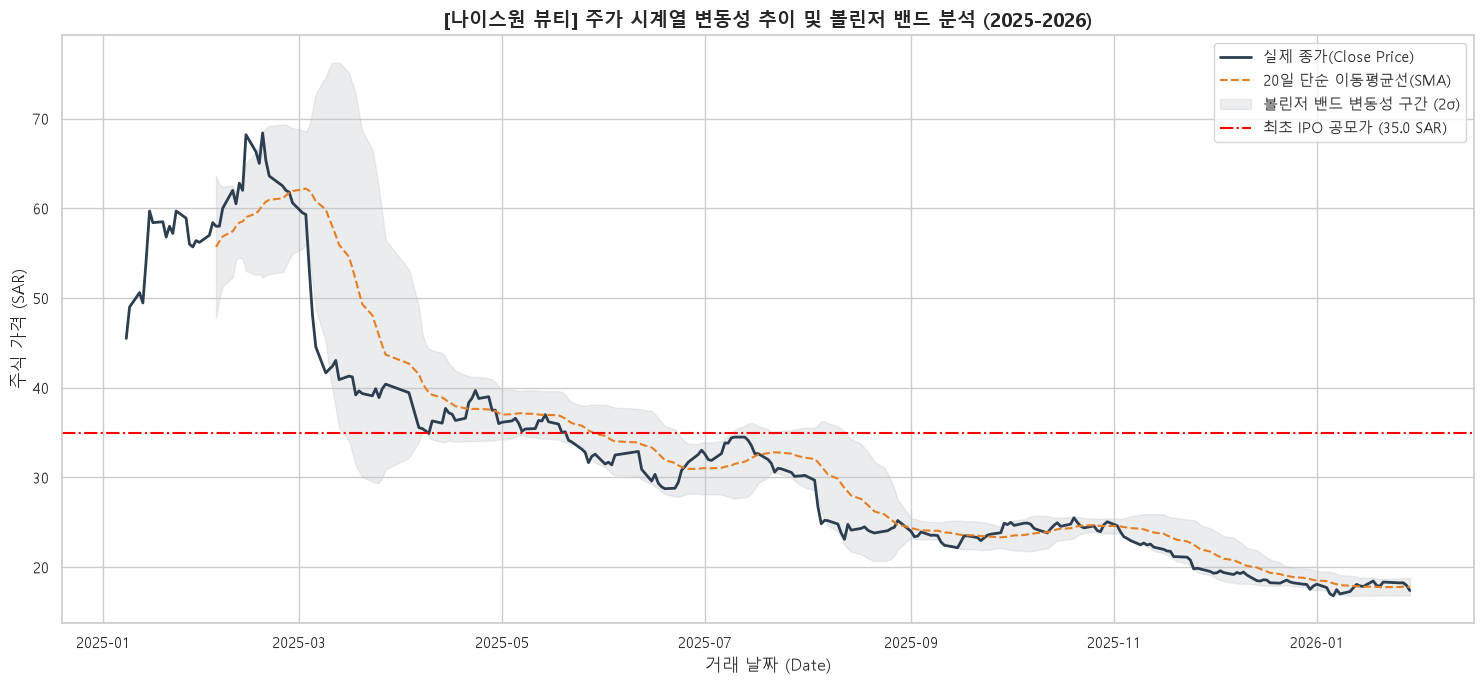

In [73]:
# Bollinger Bands calculation
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['STD_20'] = df['Close'].rolling(window=20).std()

# 상한 선과 하한선 구하기 
df['Bollinger_Upper'] = df['SMA_20'] + (df['STD_20']*2) #평균 + 표준편차 제곱
df['Bollinger_Lower'] = df['SMA_20'] - (df['STD_20']*2)

# 시각화 
plt.figure(figsize=(15,7))

plt.plot(df['Date'],df['Close'], label="실제 종가(Close Price)", color='#2c3e50',linewidth=2,)

# 20일 이동 평균선 나타내기 (20일간 롤링의 평균)
plt.plot(df['Date'],df['SMA_20'],label ="20일 단순 이동평균선(SMA)", color='#e67e22',linestyle='--',)

# 상한선과 하한선 사이 영역을 회색으로 채우기 = BOLLINGER BAND = 변동성 울타리 튜브
plt.fill_between(df['Date'], df['Bollinger_Upper'],df['Bollinger_Lower'], color='#bdc3c7',alpha=0.3,label='볼린저 밴드 변동성 구간 (2σ)',)

# 최초 공모가 기준선 그어주기 
plt.axhline(35.0,color='red', linestyle='-.',label='최초 IPO 공모가 (35.0 SAR)',)

# 디자인
plt.title("[나이스원 뷰티] 주가 시계열 변동성 추이 및 볼린저 밴드 분석 (2025-2026)",fontsize=14,
        fontweight='bold',
    )

plt.xlabel('거래 날짜 (Date)')
plt.ylabel('주식 가격 (SAR)')
plt.legend(loc='upper right')  # 이름표 상단 우측 고정

plt.tight_layout()
plt.show()

## 시계열 정상성 테스트 

- 시계열 데이터
    1. 비정상적 데이터(Non- Stationarity) : 규칙X, 시간의 흐름에 따라 평균이 계속 변함 위아래로, trend가 있음
    2. 정상성 데이터 : 평균이 0에 고정, 분산도 일정, -> 로그 수익률이 여기에 해당 -> 통계학적 규칙성이 생겨서 ai 가 더 정교하게 예측할 수 있는 상태가 됨 
    3. ADF 검정과 P-value : 귀무가설(HO):이 데이터는 분석 불가능한 비정상성 데이터이다. 가정
        - 만약 P-VALUE 가 0.05보다 작다면 귀무가설 Reject 정상성 데이터다.

- 정상성(Stationarity)과 ADF 검정(Augmented Dickey-Fuller Test)
-> 데이터가 ai, 전통적 통계 예측을 돌리기 전에 분석 가능한 상태인지 확인.
p-값 확인

계량 금융 모델링(Quantitative Financial Modeling)의 표준 요구 사항
- 시계열 데이터가 정상성(stationarity - 시간에 따라 평균과 분산이 일정한 성질)을 가졌는가 확인
- 가공되지 않은 순수 종가(CLOSE)와 일일 수익률 에 대해 각각 ADF 검사를 수행.


In [74]:
def perform_adf_test(series, name):
    print(f"\n==================================================")
    print(f"📊 [{name}] 시계열 데이터 정상성(Stationarity) ADF 검정")
    print(f"==================================================")
    
    result = adfuller(series.dropna())
    
    print(f"1) ADF 검정 통계량(statistic): {result[0]:.6f}")
    print(f"2) p-value : {result[1]:.6f}")
    print(f"critical value 합격 커트라인 기준표")
    for  key, value in result[4].items():
        print(f" {key} : {value:.6f}")
    
    print(" 최종 통계학적 해석 ")

    #result[1] = p-vlaue
    if result[1] < 0.05 :
        print(" p-value 가 0.05 미만이므로 귀무가설을 기각한다 - > 따라서 본 데이터의 경우 시간에 따라 통계 특성이 일정한 정상성 데이터이다.")
        
    else:
        print("p-value 가 0.05 이상이므로 귀무가설을 기각할 수 없습니다 = 즉 본 데이터는 비정상적 데이터입니다")

In [75]:
perform_adf_test(df['Close'], "Raw close price")


📊 [Raw close price] 시계열 데이터 정상성(Stationarity) ADF 검정
1) ADF 검정 통계량(statistic): -1.192284
2) p-value : 0.676906
critical value 합격 커트라인 기준표
 1% : -3.455461
 5% : -2.872593
 10% : -2.572660
 최종 통계학적 해석 
p-value 가 0.05 이상이므로 귀무가설을 기각할 수 없습니다 = 즉 본 데이터는 비정상적 데이터입니다


In [76]:
perform_adf_test(df['Log_Return'], "daily log returns")


📊 [daily log returns] 시계열 데이터 정상성(Stationarity) ADF 검정
1) ADF 검정 통계량(statistic): -13.984693
2) p-value : 0.000000
critical value 합격 커트라인 기준표
 1% : -3.455270
 5% : -2.872509
 10% : -2.572615
 최종 통계학적 해석 
 p-value 가 0.05 미만이므로 귀무가설을 기각한다 - > 따라서 본 데이터의 경우 시간에 따라 통계 특성이 일정한 정상성 데이터이다.


## 인터랙티브 eda : 애니메이션 시각화(plotly express)

In [77]:
!uv pip install nbformat

Checked 1 package in 531ms


In [78]:
# 1. 애니메이션 그룹화를 위한 연-월(YEAR-MONTH) 그룹화
df['Year-Month'] = df['Date'].dt.to_period('M').astype(str) # 2025-10-1, 2025-12-1 등이 있으면 달별로 끊어라 -> 2025-01, 2025-12

# 결측치 제거하고 복사해서 생성해라
animated_df = df.dropna().copy()

# 날짜를 문자열로 변환
animated_df['Date_Str'] = animated_df['Date'].dt.strftime('%Y-%m-%d')

# 산점도 시각화 만들기

fig_anim = px.scatter(
    animated_df,
    x = "Rolling_Volatility_7d",  # X축 : 7일 이동 변동성
    y = "Close", # y축은 마감 주가
    animation_frame= "Year-Month", #애니메이션 플레이 축(매해 월별)
    size = "Volume", # 원의 크기는 당일 주식 거래량
    color= "Close", # 원의 색상은 주가 에 따른 그라데이션 -> 주가가 높으면 진한 색상?
    hover_name= "Date_Str", # 마우스를 올렸을 때 팝업창에 뜰 이름은 (구체적인 날짜의 문자열)
    size_max=60, # 원의 크기의 최대 제한
    
    # 그래프 축 범위 고정
    range_x = [0, animated_df["Rolling_Volatility_7d"].max() * 1.1], 
    range_y = [
        animated_df['Close'].min() * 0.9,
        animated_df['Close'].max() * 1.1,
    ],
    labels= {
            "Rolling_Volatility_7d": "7일 이동 변동성 (위험도 수준)",
            "Close": "종가 주가 (SAR)",
            "Volume": "주식 거래량 (Traded Volume)",
    },
    title = "시간에 따른 주가 vs 변동성 역학관계 추이 (원의 크기 = 거래량)" 
)

# 차트 레이아웃 스타일링 폰트
fig_anim.update_layout(
        plot_bgcolor="white",
        paper_bgcolor="white",
        font=dict(family="Inter, Malgun Gothic, sans-serif"),
)

fig_anim.show()
fig_anim.show(renderer='iframe')


절대적인 변동성보다 상대적인 변화가 더 중요함,. 
7일 변동성 ≫ 30일 변동성: 최근 시장이 갑자기 불안정해졌을 가능성(이벤트 발생, 공포 심리 증가)
7일 변동성 ≈ 30일 변동성: 평소와 유사한 시장 환경
7일 변동성 ≪ 30일 변동성: 시장이 점차 안정되는 국면일 가능성

In [89]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 2행 2열 구조의 인터랙티브 멀티 틀 생성

fig_dash = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        '<b>주가 가치 추이(SAR) & Bollinger Bands</b>', # Stock valuation trend, 볼린저 밴드
        '<b>일일 주식 거래량(Liquidity Flows)</b>', # daily traded shares (시장 유동성 흐름)
        '<b>수익률의 확률 분산 빈도(Histogram)</b>', # 일일 주가 수익률(return)의 확률(Probability) 분포(Distribution)
        '<b>단기(7일) vs. 장기(30일) 이동 변동성 비교(Volatility Swings)</b>' # 최근 일주일이 평소(1달)보다 얼마나 흔들리는가
    ),
    vertical_spacing= 0.15, # 위아래 차트 간격 여백
    horizontal_spacing= 0.08 # 좌우 차트 간격 여백
)

# [1행 1열] 주가 가치 추이 
fig_dash.add_trace(
    go.Scatter(
        x = df['Date'],
        y = df['Close'],
        name = "실제 종가",
        line = dict(color='#2c3e50', width=2),

    ),
    row = 1,
    col = 1,
)
fig_dash.add_trace(
    go.Scatter(
        x=df['Date'],
        y=df['SMA_20'],
        name = "20일 이동평균선",
        line=dict(color='#e67e22', width=1, dash='dash'),
),
    row=1,
    col=1,
)
fig_dash.add_trace(
    go.Scatter(
        x=df['Date'],
        y=df['Bollinger_Upper'],
        name = "볼린저밴드 상한선",
        line=dict(color='#bdc3c7', width=1),
    ),
    row=1,
    col=1,
)
fig_dash.add_trace(
    go.Scatter(
        x=df['Date'],
        y=df['Bollinger_Lower'],
        name = "볼린저밴드 하한선",
        line=dict(color='#bdc3c7', width=1),
        fill='tonexty', # 상한선과 하한선 사이 색 채우기
    ),
    row=1,
    col=1,
)

#[1행 2열] 일일 주식 거래량 막대차트
fig_dash.add_trace(
    go.Bar(
        x= df['Date'], 
        y= df['Volume'],
        name = "주식 거래량",
        marker_color='#1abc9c'
    ),
    row=1,
    col=2,
)

#[2행 1열] 수익률 분포 히스토그램
fig_dash.add_trace(
    go.Histogram(
        x=df['Daily_Return'].dropna(),
        name = "수익률 빈도수",
        marker_color='#e74c3c',
        nbinsx=60,
    ),
    row=2,
    col=1,
    )

# [2행 2열] 단기, 장기 이동변동성 비교
fig_dash.add_trace(
    go.Scatter(
        x=df['Date'],
        y=df['Rolling_Volatility_7d'],
        name = "7일 단기 위험도 ",
        line=dict(color='#e74c3c', width=1.5)
        ),
    row=2,
    col=2,
)
fig_dash.add_trace(
    go.Scatter(
        x=df['Date'],
        y=df['Rolling_Volatility_30d'],
        name = "30일 단기 위험도 ",
        line=dict(color='#9b59b6', width=1.5)
        ),
    row=2,
    col=2,
)


# 대시보드 토탈 스타일링 및 마감
fig_dash.update_layout(
    height=800,
    width=1100,
    title_text="<b>나이스원뷰티 인터랙티브 금융 성과 대시보드</b>",
    title_font_size=18,
    title_font_family="Inter, Malgun Gothic, sans-serif",
    showlegend=True,
    plot_bgcolor="white",
    paper_bgcolor="white",
)

# 그리드 배경선 깔아주기
fig_dash.update_xaxes(showgrid=True, gridcolor='#f1f1f1')
fig_dash.update_yaxes(showgrid=True, gridcolor='#f1f1f1')

# 주가 차트(1행,1열)에만 기간 돋보기 버튼 추가
fig_dash.update_xaxes(
    rangeslider_visible=False,
    rangeselector=dict(
        buttons= list([
            dict(count=1, label="최근 1달", step="month",stepmode="backward"),
            dict(count=3, label="최근 3달", step="month",stepmode="backward"),
            dict(count=6, label="최근 6달", step="month",stepmode="backward"),
            dict(label="전체 기간", step="all"),
        ])
    ),
    row=1,
    col=1,
)

# 최종 출력
fig_dash.show()
fig_dash.show(renderer='iframe')